In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

In [23]:
collect_tree_levels = np.linspace(2, 10, 9, dtype=int)
# collect_tree_levels = np.linspace(2, 9, 8, dtype=int)
file_gramian = [f"../out/Convergence/ConvergenceEvenOrder/gram_solution_treelevel{tree_level}_Kn1.0_T_end0.3_rho_L7.0_rho_R1.0_v_L0.0_v_R0.0_theta_L1.0_theta_R1.0_ρ_v_p.csv" for tree_level in collect_tree_levels]
data_gramian = [pd.read_csv(f) for f in file_gramian]

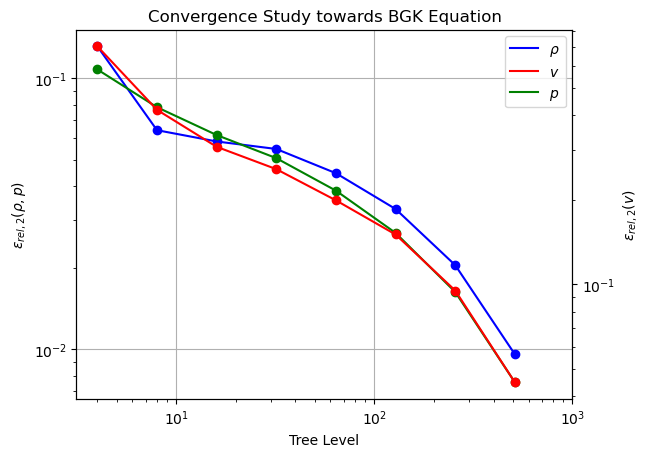

In [60]:
errors = {}
Nx = []
for key in ['rho', 'v', 'p']:
    errors[key] = []
    ref_solution = interp1d(data_gramian[-1]['x'], data_gramian[-1][key])  # Using the same data as reference for simplicity
    for tree_level in collect_tree_levels[:-1]:
        data_trixi = data_gramian[collect_tree_levels.tolist().index(tree_level)]
        error = np.linalg.norm(ref_solution(data_trixi['x']) - data_trixi[key], 2) / np.linalg.norm(ref_solution(data_trixi['x']), 2)
        errors[key].append(error)
        if key == 'rho':
            Nx.append(2**tree_level) # Assuming 3 cells per leaf node -> * 3 in the brackets

fig, axs = plt.subplots()
axs.loglog(Nx, errors['rho'], marker='o', color='blue')
twinx = axs.twinx()
twinx.loglog(Nx, errors['v'], marker='o', color='red')
axs.loglog(Nx, errors['p'], marker='o', color='green')
axs.plot([], [], 'b-', label='$\\rho$')
axs.plot([], [], 'r-', label='$v$')
axs.plot([], [], 'g-', label='$p$')
axs.set_xticks([10**1, 10**2, 10**3])
axs.set_xlabel('Tree Level')
axs.set_ylabel('$\\epsilon_{rel,2}(\\rho, p)$')
twinx.set_ylabel('$\\epsilon_{rel,2}(v)$')
axs.set_title('Convergence Study towards BGK Equation')
axs.grid(True)
axs.legend()

In [55]:
Nx

[4, 8, 16, 32, 64, 128, 256, 512]